# Issue Resistance: Do Counties Vote Their Conscience Against Their Party? (Module 2, path b)

*An analysis notebook for the Geo-Fluid Dynamics Engine. This is exploratory
narrative — it calls the project's tested library (`geofluid`) for the real
computation and tells the story around it.*

## The question, and why we are here

Module 2 (the Gravity Engine) asks where political influence and resistance
live on the map. Two earlier attempts to read it off **presidential swing**
were falsified: contemporaneous co-movement collapsed (everyone co-moves —
swing is too spatially autocorrelated), and a lead-lag timing retry was weak
and spatially incoherent. The diagnosis both times: presidential vote is too
synchronized and too sticky to localize who resists the partisan tide.

Path (b) reframes the question through **single-issue ballot measures**. When a
county votes far more progressively on a specific issue than its partisan
identity predicts, it is *resisting* its own party on that question — the spec's
**"False Bastion."** Abortion referendums are the cleanest probe available: a
yes/no question, decided the same year across very different partisan contexts.

A single measure is one observation per county (N=1) — no structure to model.
So we use the **starter set** of three abortion measures, stacked by
`geofluid.panel.measures.build_measures_panel` into one tidy `fips x measure_id`
panel with an orientation-corrected `progressive_share`:

* **Kansas**, Aug 2022 — a NO defeated an abortion ban (deep red)
* **Kentucky**, Nov 2022 — a NO blocked a "no right to abortion" amendment (deep red)
* **Ohio** Issue 1, Nov 2023 — a YES established a right to abortion (purple)

Ohio flips the ballot polarity (YES is the pro-choice vote), which is exactly
why `progressive_share` is orientation-corrected: 0.70 means "70% voted the
pro-choice way" in all three, comparable across the set.

**Resistance** is then the same gap Module 3 already measures, generalized
across measures: `resistance = progressive_share - partisan_share`, where the
partisan baseline is the 2020 Democratic two-party presidential share. Positive
resistance = a county ran ahead of its partisanship on abortion rights.

## The bottom line (plain language)

**Abortion rights outran the Democratic brand almost everywhere — but the
effect is broad, not concentrated in special "bastions."** Across all three
states, *every* county voted more pro-choice than it voted Democratic in 2020,
by a roughly uniform ~13-19 points. The hoped-for sharp gradient — resistance
spiking in particular deep-red counties — is only a weak second-order wrinkle
(correlation -0.10 to -0.23 with partisanship). So issue resistance cleanly
separates the *measure* from the *party*, but it does **not** yet cleanly
separate *counties* from each other — the same "faint localized structure"
wall the swing-based Module 2 attempts hit, approached from the issue side.
The unfinished question — is resistance a stable *county* trait across
different issues? — needs overlapping geography, which points straight at
Ohio's cannabis measure (same 88 counties) as the next ingest.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from geofluid.ingest.county_geometry import county_shapefile_to_geojson
from geofluid.ingest.county_returns import load_county_returns
from geofluid.ingest.referendum import (
    load_ks_referendum_workbook,
    load_ky_referendum,
    load_oh_referendum,
)
from geofluid.panel.measures import Measure, build_measures_panel

# Resolve the repo root so data paths work however the notebook is executed
# (the kernel's CWD is the notebooks/ directory, not the repo root).
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())

# County NAME|state -> FIPS from our own boundary file (the same join the web
# export uses). Each loader gets the names for its own state.
GEO = county_shapefile_to_geojson(str(ROOT / "data/raw/cb_2021/cb_2021_us_county_500k.shp"))
NAME_STATE_TO_FIPS = {
    f["properties"]["NAME"].upper() + "|" + f["id"][:2]: f["id"] for f in GEO["features"]
}


def names_for(state: str) -> dict[str, str]:
    return {n.split("|")[0]: f for n, f in NAME_STATE_TO_FIPS.items() if n.endswith("|" + state)}


# Each measure: its loader, source file, state, and which ballot side was the
# progressive (pro-choice) vote — the orientation build_measures_panel needs.
SPECS = [
    (
        "ks_abortion_2022",
        "20",
        "no",
        load_ks_referendum_workbook,
        "data/raw/ks_amendment_2022_precinct.xlsx",
    ),
    (
        "ky_abortion_2022",
        "21",
        "no",
        load_ky_referendum,
        "data/raw/2022 Kentucky Amendment 2 - No Right To Abortion Election Results.txt",
    ),
    ("oh_abortion_2023", "39", "yes", load_oh_referendum, "data/raw/precinct-summary.xlsx"),
]

measures = [
    Measure(measure_id=mid, progressive_side=side, panel=loader(str(ROOT / src), names_for(state)))
    for mid, state, side, loader, src in SPECS
]
panel = build_measures_panel(measures)
print(panel.groupby("measure_id").size())
panel.head()

measure_id
ks_abortion_2022    105
ky_abortion_2022    120
oh_abortion_2023     88
dtype: int64


side,measure_id,fips,yes_votes,no_votes,total_votes,no_share,progressive_share
0,ks_abortion_2022,20001,1859,1847,3706,0.498381,0.498381
1,ks_abortion_2022,20003,1450,970,2420,0.400826,0.400826
2,ks_abortion_2022,20005,2501,2482,4983,0.498094,0.498094
3,ks_abortion_2022,20007,1011,468,1479,0.316430,0.316430
4,ks_abortion_2022,20009,4057,3329,7386,0.450718,0.450718


## Join the partisan baseline and compute resistance

The baseline is each county's 2020 Democratic two-party presidential share —
the same baseline the map's dissonance overlay uses. `resistance =
progressive_share - dem_share_2p`. We keep counties with a baseline (every
county in these three states has one) and carry the partisanship along so we
can ask how resistance varies with how red a county is.

In [2]:
returns = load_county_returns(pd.read_csv(ROOT / "data/raw/countypres_2000-2024.csv"))
baseline = returns[returns["year"] == 2020].set_index("fips")["dem_share_2p"]

panel["partisanship"] = panel["fips"].map(baseline)
panel["resistance"] = panel["progressive_share"] - panel["partisanship"]
print("counties with no 2020 baseline:", int(panel["partisanship"].isna().sum()))

summary = panel.groupby("measure_id").agg(
    counties=("fips", "size"),
    median_progressive=("progressive_share", "median"),
    median_partisanship=("partisanship", "median"),
    median_resistance=("resistance", "median"),
    min_resistance=("resistance", "min"),
    max_resistance=("resistance", "max"),
)
summary.round(3)

counties with no 2020 baseline: 0


,counties,median_progressive,median_partisanship,median_resistance,min_resistance,max_resistance
measure_id,,,,,,
ks_abortion_2022,105,0.417,0.194,0.190,0.058,0.315
ky_abortion_2022,120,0.413,0.233,0.170,0.075,0.311
oh_abortion_2023,88,0.421,0.288,0.135,0.005,0.223


## The False Bastion gradient: resistance vs. how red a county is

If abortion vote simply tracked party, `progressive_share` would equal
`partisanship` and resistance would be ~0 everywhere. The False Bastion thesis
is the opposite: abortion is **less polarized than party**, so the pro-choice
share is *compressed* toward the middle — and the reddest counties, far below
50% Democratic, end up voting far more pro-choice than their party. That
predicts resistance **falling as partisanship rises** (a negative slope), and a
fitted line `progressive_share ~ partisanship` with **slope < 1** (compression).

We fit that line per measure and report the slope, the correlation of
resistance with partisanship, and how many counties are net resisters
(resistance > 0).

In [3]:
rows = []
for mid, g in panel.groupby("measure_id"):
    slope, intercept = np.polyfit(g["partisanship"], g["progressive_share"], 1)
    rows.append(
        {
            "measure_id": mid,
            "compression_slope": slope,  # < 1 => issue flatter than party
            "intercept_at_0_dem": intercept,  # pro-choice share a 0%-Dem county would cast
            "corr_resist_vs_partisan": g["resistance"].corr(g["partisanship"]),
            "pct_net_resisters": (g["resistance"] > 0).mean(),
        }
    )
gradient = pd.DataFrame(rows).set_index("measure_id")
gradient.round(3)

,compression_slope,intercept_at_0_dem,corr_resist_vs_partisan,pct_net_resisters
measure_id,,,,
ks_abortion_2022,0.900,0.214,-0.233,1.0
ky_abortion_2022,0.955,0.182,-0.096,1.0
oh_abortion_2023,0.934,0.150,-0.175,1.0


## See it: pro-choice share vs. partisanship, one panel per state

The diagonal is "abortion vote = party." The fitted line flatter than the
diagonal is the compression. Points above the diagonal are False Bastions
(more pro-choice than partisan); the gap between the line and the diagonal in
the red (left) half of each panel is the resistance the engine is after.

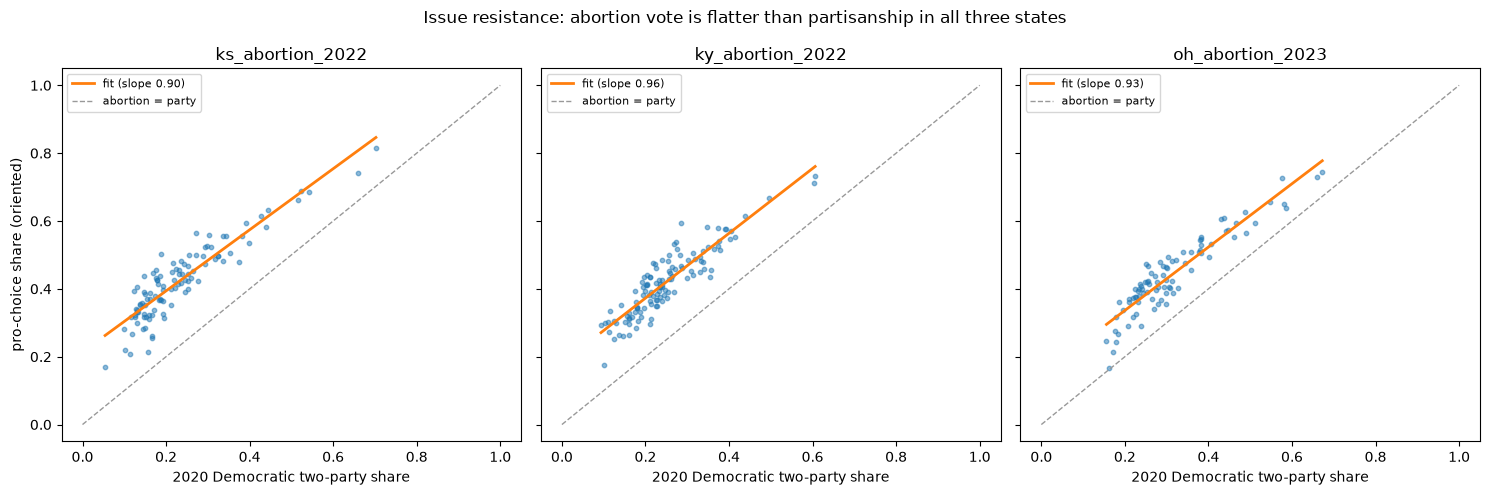

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, (mid, g) in zip(axes, panel.groupby("measure_id"), strict=False):
    ax.scatter(g["partisanship"], g["progressive_share"], s=10, alpha=0.5)
    xs = np.array([g["partisanship"].min(), g["partisanship"].max()])
    slope, intercept = np.polyfit(g["partisanship"], g["progressive_share"], 1)
    ax.plot(xs, slope * xs + intercept, color="C1", lw=2, label=f"fit (slope {slope:.2f})")
    ax.plot([0, 1], [0, 1], color="0.6", ls="--", lw=1, label="abortion = party")
    ax.set_title(mid)
    ax.set_xlabel("2020 Democratic two-party share")
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("pro-choice share (oriented)")
fig.suptitle("Issue resistance: abortion vote is flatter than partisanship in all three states")
fig.tight_layout()
plt.show()

## Who are the strongest False Bastions?

The counties with the largest positive resistance — deep-red places that voted
heavily to protect abortion rights. These are the engine's targets: where a
specific issue runs furthest ahead of partisan identity.

In [5]:
top = panel.nlargest(12, "resistance")[
    ["measure_id", "fips", "partisanship", "progressive_share", "resistance"]
]
top.round(3).reset_index(drop=True)

side,measure_id,fips,partisanship,progressive_share,resistance
0,ks_abortion_2022,20073,0.189,0.504,0.315
1,ky_abortion_2022,21181,0.284,0.595,0.311
2,ks_abortion_2022,20139,0.272,0.564,0.291
3,ks_abortion_2022,20049,0.146,0.437,0.291
4,ks_abortion_2022,20167,0.177,0.456,0.279
5,ks_abortion_2022,20075,0.168,0.446,0.278
6,ks_abortion_2022,20101,0.131,0.406,0.275
7,ks_abortion_2022,20071,0.124,0.393,0.269
8,ky_abortion_2022,21041,0.274,0.539,0.265
9,ky_abortion_2022,21103,0.268,0.533,0.264


## What this shows — and what it cannot (yet)

*(The honest read, written after seeing the real numbers above — which did not
match the tidy "red bastions decouple" story this notebook set out to find.)*

**The dominant signal is a near-uniform OFFSET, not a gradient.** In all three
states, **every single county** ran ahead of its 2020 Democratic share on
abortion rights (100% net resisters; even the bluest county's resistance is
barely above zero, and the reddest are the most positive). The fitted line is
`progressive_share ≈ partisanship + ~0.15-0.21` — a slope just *below* 1
(0.90 KS, 0.96 KY, 0.93 OH) with a large positive intercept. Read plainly:
abortion-rights support sits ~13-19 points **above** the Democratic brand
almost everywhere, in a roughly parallel shift. The "False Bastion" is real as
an **aggregate** fact — these states backed abortion rights well beyond how
they vote for president — but it is broad, not concentrated.

**The county-level gradient — the part that would LOCALIZE resistance — is
weak.** Resistance does fall as counties get bluer (corr -0.23 KS, -0.10 KY,
-0.18 OH), and the reddest counties show the largest gaps (the top False
Bastions are deep-red western-Kansas and Appalachian-Kentucky counties at
+0.28 to +0.32). But that gradient is a second-order wrinkle on top of the big
flat offset. This is the **same lesson the swing-based Module 2 attempts hit
from the other side**: the interesting *localized* structure is faint relative
to a strong aggregate effect. Issue resistance cleanly separates the *measure*
from the *party* — it does not yet cleanly separate *counties* from each other.

**The hard limit: disjoint geographies.** These three measures cover three
*different* sets of counties, so no county appears twice. We can see the offset
and the weak gradient repeat across three independent contexts (which is itself
worth something — it is not a Kansas quirk), but we cannot ask the sharper
question: is *a given county's* resistance a stable trait — the same county
resisting issue after issue? That needs **overlapping geography**.

**The next data, and why it is the natural next step.** Ohio's Nov-2023 ballot
carried a SECOND statewide question — Issue 2, recreational cannabis — decided
by the **same 88 counties** on the same day. Ingesting Issue 2 (already in the
same source file, the second Yes/No pair) would let us put abortion resistance
and cannabis resistance side by side *per county* and finally test whether
persuadability is **issue-general** (the counties that resist on abortion also
resist on cannabis) or **issue-specific**. If resistance is a stable county
trait, that — not the weak within-issue gradient — is where Module 2 path (b)
would finally find structure. That is the JIT trigger this notebook surfaces
for the next ingest.